1: Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sklearn
print(sklearn.__version__)

1.8.0


In [4]:
import sys
print(sys.executable)


c:\Users\ALI COMPUTER\Desktop\Assignment 5\myenv\Scripts\python.exe


In [5]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn xgboost matplotlib

'c:\Users\ALI' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import sklearn
print(f"Path: {sklearn.__file__}")
print(f"Version: {sklearn.__version__}")

Path: c:\Users\ALI COMPUTER\Desktop\Assignment 5\myenv\Lib\site-packages\sklearn\__init__.py
Version: 1.8.0


In [7]:
import sys
import sklearn
print(f"Current Python: {sys.executable}")
print(f"Sklearn Version: {sklearn.__version__}")

Current Python: c:\Users\ALI COMPUTER\Desktop\Assignment 5\myenv\Scripts\python.exe
Sklearn Version: 1.8.0


In [17]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall scikit-learn pandas numpy matplotlib seaborn xgboost

'c:\Users\ALI' is not recognized as an internal or external command,
operable program or batch file.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, auc, roc_auc_score, 
                             brier_score_loss, precision_score, recall_score, 
                             f1_score, confusion_matrix)
# Use this instead of CalibrationDisplay
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

2: Stratified Split (70/15/15)

In [23]:
import pandas as pd

# Load the data
url = "https://raw.githubusercontent.com/bipin-a/ml-workshop/main/training/data.csv"
df = pd.read_csv(url)

# Clean column names (the assignment dataset has trailing spaces)
df.columns = df.columns.str.strip()

print("Data loaded successfully!")

Data loaded successfully!


In [24]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# First split: 70% Train, 30% for Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Split the 30% into two 15% chunks
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Verify for rubric
for name, target in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name} split bankrupt %: {target.mean():.4f}")

Train split bankrupt %: 0.0323
Val split bankrupt %: 0.0323
Test split bankrupt %: 0.0323


3: Reusable Evaluation Function

In [25]:
def get_metrics(model, X_set, y_set, threshold=0.5):
    probs = model.predict_proba(X_set)[:, 1]
    preds = (probs >= threshold).astype(int)
    
    # Primary Metrics
    prec_pts, rec_pts, _ = precision_recall_curve(y_set, probs)
    pr_auc = auc(rec_pts, prec_pts)
    brier = brier_score_loss(y_set, probs)
    
    # Secondary Metrics
    roc_auc = roc_auc_score(y_set, probs)
    f1 = f1_score(y_set, preds)
    recall = recall_score(y_set, preds)
    precision = precision_score(y_set, preds, zero_division=0)
    
    return {
        "pr_auc": pr_auc, "brier": brier, "roc_auc": roc_auc,
        "f1": f1, "recall": recall, "precision": precision
    }

4: The 5 Experiments

In [26]:
results = []

# Helper to log results
def log_exp(id, name, feat_set, settings, model, xt, yt, xv, yv):
    tr = get_metrics(model, xt, yt)
    vl = get_metrics(model, xv, yv)
    results.append({
        "exp_id": id, "model": name, "feature_set": feat_set, "main_settings": settings,
        "train_pr_auc": tr['pr_auc'], "val_pr_auc": vl['pr_auc'], 
        "overfit_gap": tr['pr_auc'] - vl['pr_auc'], "val_roc_auc": vl['roc_auc'],
        "val_brier": vl['brier'], "val_recall": vl['recall'], "val_f1": vl['f1']
    })

# 1. Baseline: Logistic Regression
sc = StandardScaler()
xt_s = sc.fit_transform(X_train); xv_s = sc.transform(X_val)
lr = LogisticRegression(max_iter=1000).fit(xt_s, y_train)
log_exp(1, "LogisticReg", "A", "StandardScaler", lr, xt_s, y_train, xv_s, y_val)

# 2. XGBoost Baseline
xgb1 = XGBClassifier(random_state=42).fit(X_train, y_train)
log_exp(2, "XGB_Base", "A", "Default", xgb1, X_train, y_train, X_val, y_val)

# 3. XGBoost + Imbalance Handling
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb2 = XGBClassifier(scale_pos_weight=ratio, random_state=42).fit(X_train, y_train)
log_exp(3, "XGB_Weighted", "A", f"scale_pos={ratio:.2f}", xgb2, X_train, y_train, X_val, y_val)

# 4. XGBoost Tuned
xgb3 = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42).fit(X_train, y_train)
log_exp(4, "XGB_Tuned", "A", "Depth=4, LR=0.05", xgb3, X_train, y_train, X_val, y_val)

# 5. XGBoost Selected Features (Feature Set B)
top_20 = pd.Series(xgb1.feature_importances_, index=X.columns).sort_values(ascending=False).head(20).index.tolist()
xgb4 = XGBClassifier(random_state=42).fit(X_train[top_20], y_train)
log_exp(5, "XGB_Top20", "B", "Top 20 Features", xgb4, X_train[top_20], y_train, X_val[top_20], y_val)

# Display Table
pd.DataFrame(results)

,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,val_recall,val_f1
0,1,LogisticReg,A,StandardScaler,0.528847,0.247205,0.281641,0.876645,0.031581,0.181818,0.235294
1,2,XGB_Base,A,Default,1.000000,0.470020,0.529980,0.952709,0.023819,0.303030,0.408163
2,3,XGB_Weighted,A,scale_pos=29.99,1.000000,0.475670,0.524330,0.958157,0.023838,0.363636,0.436364
3,4,XGB_Tuned,A,"Depth=4, LR=0.05",0.992444,0.529319,0.463126,0.961769,0.020492,0.272727,0.400000
4,5,XGB_Top20,B,Top 20 Features,1.000000,0.378606,0.621394,0.936394,0.026017,0.272727,0.346154


5: Final Evaluation & Calibration (Manual Fix)

In [28]:
import matplotlib.pyplot as plt

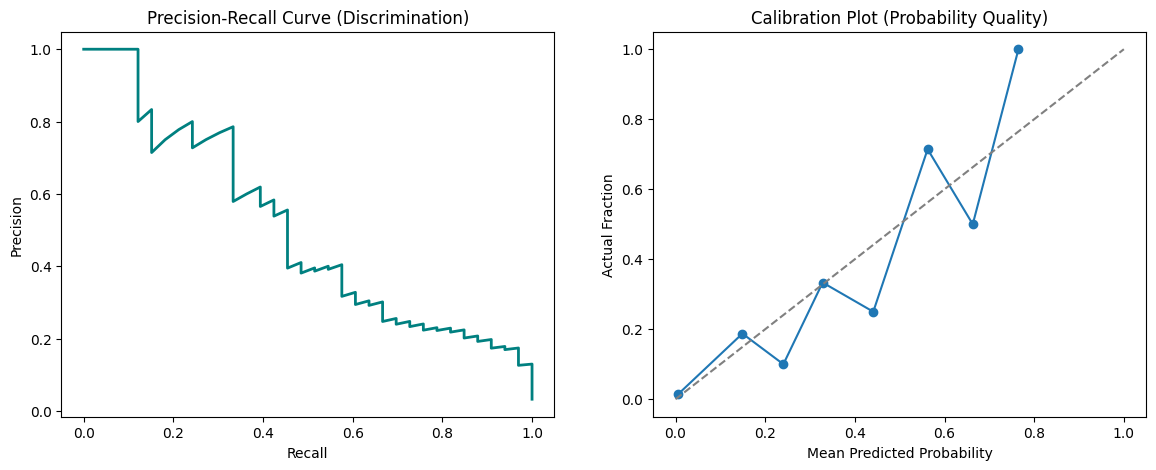

In [29]:
# Assuming Exp 4 was the winner
final_model = xgb3

def plot_final_results(model, X_set, y_set):
    probs = model.predict_proba(X_set)[:, 1]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_set, probs)
    ax[0].plot(r, p, color='teal', lw=2)
    ax[0].set_title("Precision-Recall Curve (Discrimination)")
    ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
    
    # 2. Calibration Curve (Manual Implementation)
    prob_true, prob_pred = calibration_curve(y_set, probs, n_bins=10)
    ax[1].plot(prob_pred, prob_true, marker='o', label="Model")
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Perfectly Calibrated")
    ax[1].set_title("Calibration Plot (Probability Quality)")
    ax[1].set_xlabel("Mean Predicted Probability"); ax[1].set_ylabel("Actual Fraction")
    plt.show()

plot_final_results(final_model, X_test, y_test)